In [9]:
import ROOT
canvas = ROOT.TCanvas("canvas", "canvas", 600, 800)

In [2]:
sim_file_name = "/lustre/r3b/pulrich/Down/sim/4GeV.output.root"

file = ROOT.TFile(sim_file_name, "read")

In [6]:
data_tree = file.Get("evt;8")
data_frame = ROOT.RDataFrame(data_tree, {"NeulandPoints.fELoss"})

In [39]:
hist = data_frame.Define("energy", "NeulandPoints.fELoss * 1000 / 5").Histo1D(("hist", "hist", 400, 0, 3), "energy")

****************************************
Minimizer is Minuit2 / Migrad
Chi2                      =      72.2847
NDf                       =           21
Edm                       =  1.11612e-07
NCalls                    =          105
Constant                  =      16653.1   +/-   39.9684     
Mean                      =      1.73165   +/-   0.000605445 
Sigma                     =     0.133052   +/-   0.00164639   	 (limited)

Covariance Matrix:

            	    Constant        Mean       Sigma
Constant    	      1597.5   0.0029968   -0.047548
Mean        	   0.0029968  3.6656e-07 -2.9887e-07
Sigma       	   -0.047548 -2.9887e-07  2.7107e-06

Correlation Matrix:

            	    Constant        Mean       Sigma
Constant    	           1     0.12384    -0.72256
Mean        	     0.12384           1    -0.29982
Sigma       	    -0.72256    -0.29982           1


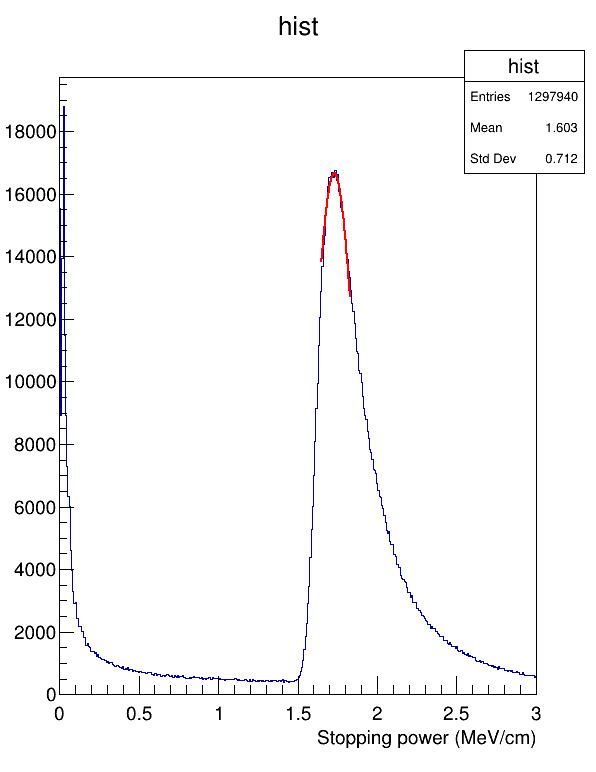

In [74]:
res = hist.Fit("gaus", "SQ", "", 1.65, 1.83)
hist.GetXaxis().SetTitle("Stopping power (MeV/cm)")
res.Print("V")
hist.Draw()
canvas.Draw()

In [58]:
!neuland ana -c "ana_config.json"

[INFO] R3BNeulandApp.h:192:ParseApplicationOptionImp(): Reading the configuration from the json file "ana_config.json".
[INFO] R3BNeulandApp.cxx:78:init(): Initializaing application ...
OBJ: FairParRootFile	/lustre/r3b/pulrich/Down/sim/4GeV.par.root	 : 0 at: 0x2f030560
Root file I/O /lustre/r3b/pulrich/Down/sim/4GeV.par.root is open
detector I/Os:  FairGenericParIo
Info in <TGeoManager::CloseGeometry>: Geometry loaded from file...
Info in <TGeoManager::SetTopVolume>: Top volume is cave. Master volume is cave
Info in <TGeoNavigator::BuildCache>: --- Maximum geometry depth set to 100
Info in <TGeoManager::Voxelize>: Voxelizing...
Info in <TGeoManager::CountLevels>: max level = 3, max placements = 1300
Info in <TGeoManager::CloseGeometry>: 5202 nodes/ 6 volume UID's in FAIR geometry
Info in <TGeoManager::CloseGeometry>: ----------------modeler ready----------------
OBJ: FairParRootFile	/lustre/r3b/pulrich/Down/sim/4GeV.par.root	 : 0 at: 0x2f030560
Root file I/O /lustre/r3b/pulrich/Down/si

In [61]:
ana_file_name = "/lustre/r3b/ywang/test/test_muon/ana.output.root"
# hit_file = ROOT.TFile(ana_file_name, "read")
# hit_file.Get("evt;3").Print()

hit_dataframe = ROOT.RDataFrame("evt", ana_file_name, {"NeulandHits.energy"})

In [66]:
hit_hist = hit_dataframe.Define("stopping_power", "NeulandHits.energy / 5").Histo1D(("hit_hist", "hit_hist", 400, 0., 3), "stopping_power")

****************************************
Minimizer is Minuit2 / Migrad
Chi2                      =      24.0646
NDf                       =           17
Edm                       =   1.7994e-07
NCalls                    =          126
Constant                  =      13343.2   +/-   36.6523     
Mean                      =      1.70199   +/-   0.00158672  
Sigma                     =     0.148055   +/-   0.00398495   	 (limited)

Covariance Matrix:

            	    Constant        Mean       Sigma
Constant    	      1343.4    0.012011   -0.085843
Mean        	    0.012011  2.5177e-06 -4.7719e-06
Sigma       	   -0.085843 -4.7719e-06  1.5882e-05

Correlation Matrix:

            	    Constant        Mean       Sigma
Constant    	           1     0.20652     -0.5877
Mean        	     0.20652           1    -0.75464
Sigma       	     -0.5877    -0.75464           1


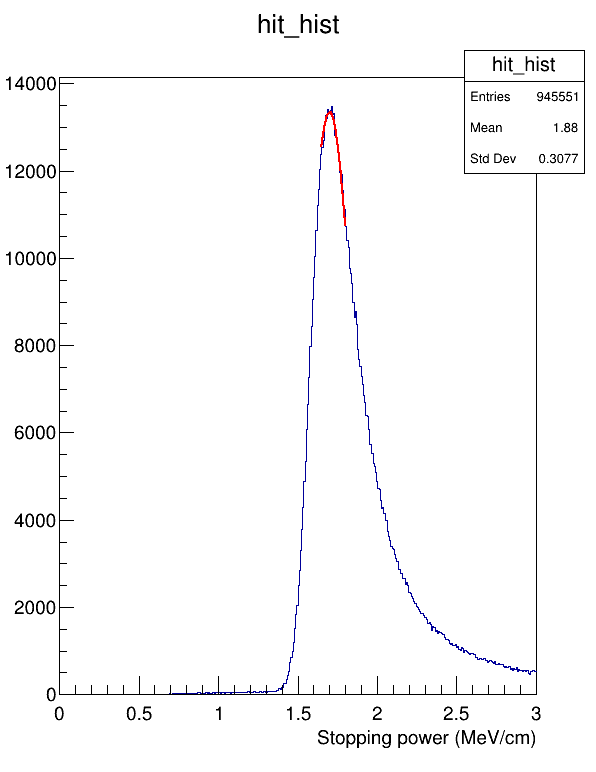

In [73]:
res = hit_hist.Fit("gaus", "SQ", "", 1.65, 1.8)
hit_hist.GetXaxis().SetTitle("Stopping power (MeV/cm)")
res.Print("V")
hit_hist.Draw()
canvas.Draw()
hit_hist.Draw()
canvas.Draw()